In [1]:
import os
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import torch

def load_tensorboard_events(file_path):
    # Create an EventAccumulator to load the event file.
    # The 'size_guidance' argument can be used to control how many items to load for each type.
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 1000,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file

    # Print available tags
    tags = ea.Tags()
    print("Available Tags:", tags)

    # For example, to print all scalar events for each scalar tag:
    if 'scalars' in tags:
        for tag in tags['scalars']:
            print(f"\nScalar values for tag: {tag}")
            events = ea.Scalars(tag)
            for event in events:
                print(f"Step: {event.step}, Value: {event.value}")
                

def load_tensorboard_metrics(file_path):
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 100,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file
    tags = ea.Tags()
    metrics = tags['scalars']
    
    return_dict = {
        'best_model_epoch': None,
        'in-domain test metric (per sample)': None,
        'test metric (per sample)': None,
    }
    
    for tag in metrics:
        if 'in-domain test metric' in tag:
            return_dict['in-domain test metric (per sample)'] = ea.Scalars(tag)[0].value
            return_dict['best_model_epoch'] = ea.Scalars(tag)[0].step   
        elif 'test metric' in tag:
            return_dict['test metric (per sample)'] = ea.Scalars(tag)[0].value
    return return_dict  


def load_series_metrics(tensor_board_dir, model_metrics):
    unmatched_sub_fodlers = []
    sub_fodlers = os.listdir(tensor_board_dir)
    models = model_metrics.keys()
    for sub_folder in sub_fodlers:
        sub_folder_path = os.path.join(tensor_board_dir, sub_folder)
        files = os.listdir(sub_folder_path)
        # find the key that in the sub_folder
        key = None
        for model in models:
            if model in sub_folder:
                key = model
                break
        if key is None:
            unmatched_sub_fodlers.append(sub_folder)
            continue
        for file in files:
            if file.startswith("events.out.tfevents"):
                file_path = os.path.join(sub_folder_path, file)
                metrics = load_tensorboard_metrics(file_path)
                metrics['sub_folder'] = sub_folder
                model_metrics[key].append(metrics)
    return model_metrics, unmatched_sub_fodlers


def MPJPE_2D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 2)
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 2)
    labels = labels.reshape(labels.shape[0], -1, 2)
    per_sample_mpjpe = np.mean(np.abs(np.linalg.norm(predicts - labels, axis=2)), axis=1)
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

def MPJPE_3D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 3) 
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 3)
    labels = labels.reshape(labels.shape[0], -1, 3)
    per_sample_mpjpe = np.mean(np.linalg.norm(predicts - labels, axis=2), axis=1)
    # if there is any value less than 0, print the index
    if np.any(per_sample_mpjpe < 0):
        print("less than 0")
        print(np.where(per_sample_mpjpe < 0))
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

### WiP-pose

#### RF-CRATE

In [2]:
all_results_folder = [
    'logs/OctonetMini/',
    'logs/ablation_OctonetMini/',
]

results_files =[
 'OctonetMini_rfcrate_small_ssr_2_rf_crate_small_0319170431',
 'OctonetMini_ssr_0_rf_crate_small_0303174856',
 ]

model_names = [
    'w/ SSR',
    'w/o SSR',
    ]


metric_list = []
predicts_list = []
labels_list = []

for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        metric_list.append(results['metrics'])
        predicts_list.append(results['predicts'])
        labels_list.append(results['labels'])


mpjpe_list = []
for predicts, labels in zip(predicts_list, labels_list):
    mpjpe_temp = []
    for i in range(len(predicts)):
        mpjpe = MPJPE_3D(predicts[i], labels[i])  # one batch
        mpjpe_temp += mpjpe.tolist()
    mpjpe_list.append(mpjpe_temp)


mpjpe_mean = np.array([np.mean(mpjpe) for mpjpe in mpjpe_list])
std_mpjpe = np.array([np.std(mpjpe) for mpjpe in mpjpe_list])
for index, name in enumerate(model_names):
    print(f'{name}: {mpjpe_mean[index]/10:.2f} ± {std_mpjpe[index]/10:.2f}')


with_ssr_mpjpe = mpjpe_mean[0]
without_ssr_mpjpe = mpjpe_mean[1]

# Calculate absolute improvement (lower MPJPE is better)
absolute_improvement = without_ssr_mpjpe - with_ssr_mpjpe
# Calculate relative improvement (percentage)
relative_improvement = (absolute_improvement / without_ssr_mpjpe) * 100

print("\nPerformance Gain from SSR:")
print(f"With SSR: {with_ssr_mpjpe/10:.2f} cm")
print(f"Without SSR: {without_ssr_mpjpe/10:.2f} cm")
print(f"Absolute improvement: {absolute_improvement/10:.2f} cm")
print(f"Relative improvement: {relative_improvement:.2f}%")

rf_crate_WiP_pose_gain = relative_improvement


w/ SSR: 28.12 ± 27.02
w/o SSR: 86.42 ± 12.67

Performance Gain from SSR:
With SSR: 28.12 cm
Without SSR: 86.42 cm
Absolute improvement: 58.31 cm
Relative improvement: 67.47%


#### Real-imag Complex SwinT

In [3]:
all_results_folder = [
    'logs/OctonetMini/',
    'logs/OctonetMini/',
]

results_files =[
 'OctonetMini_complex_swin_t_ssr_complex_swin_t_0414232456',
 'OctonetMini_complex_swin_t_complex_swin_t_0414232041',
 ]

model_names = [
    'w/ SSR',
    'w/o SSR',
    ]


metric_list = []
predicts_list = []
labels_list = []

for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        metric_list.append(results['metrics'])
        predicts_list.append(results['predicts'])
        labels_list.append(results['labels'])


mpjpe_list = []
for predicts, labels in zip(predicts_list, labels_list):
    mpjpe_temp = []
    for i in range(len(predicts)):
        mpjpe = MPJPE_3D(predicts[i], labels[i])  # one batch
        mpjpe_temp += mpjpe.tolist()
    mpjpe_list.append(mpjpe_temp)


mpjpe_mean = np.array([np.mean(mpjpe) for mpjpe in mpjpe_list])
std_mpjpe = np.array([np.std(mpjpe) for mpjpe in mpjpe_list])
for index, name in enumerate(model_names):
    print(f'{name}: {mpjpe_mean[index]/10:.2f} ± {std_mpjpe[index]/10:.2f}')
    
with_ssr_mpjpe = mpjpe_mean[0]
without_ssr_mpjpe = mpjpe_mean[1]

# Calculate absolute improvement (lower MPJPE is better)
absolute_improvement = without_ssr_mpjpe - with_ssr_mpjpe
# Calculate relative improvement (percentage)
relative_improvement = (absolute_improvement / without_ssr_mpjpe) * 100

print("\nPerformance Gain from SSR:")
print(f"With SSR: {with_ssr_mpjpe/10:.2f} cm")
print(f"Without SSR: {without_ssr_mpjpe/10:.2f} cm")
print(f"Absolute improvement: {absolute_improvement/10:.2f} cm")
print(f"Relative improvement: {relative_improvement:.2f}%")

real_img_complex_swin_t_WiP_pose_gain = relative_improvement


w/ SSR: 39.88 ± 21.84
w/o SSR: 39.89 ± 21.80

Performance Gain from SSR:
With SSR: 39.88 cm
Without SSR: 39.89 cm
Absolute improvement: 0.02 cm
Relative improvement: 0.04%


#### Phase-Amp Complex SwinT

In [4]:
all_results_folder = [
    'logs/OctonetMini/',
    'logs/OctonetMini/',
]

results_files =[
 'OctonetMini_complex_ampha_swin_t_ssr_complex_ampha_swin_t_0421213642',
 'OctonetMini_complex_ampha_swin_t_complex_ampha_swin_t_0421213845',
 ]

model_names = [
    'w/ SSR',
    'w/o SSR',
    ]


metric_list = []
predicts_list = []
labels_list = []

for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        metric_list.append(results['metrics'])
        predicts_list.append(results['predicts'])
        labels_list.append(results['labels'])


mpjpe_list = []
for predicts, labels in zip(predicts_list, labels_list):
    mpjpe_temp = []
    for i in range(len(predicts)):
        mpjpe = MPJPE_3D(predicts[i], labels[i])  # one batch
        mpjpe_temp += mpjpe.tolist()
    mpjpe_list.append(mpjpe_temp)


mpjpe_mean = np.array([np.mean(mpjpe) for mpjpe in mpjpe_list])
std_mpjpe = np.array([np.std(mpjpe) for mpjpe in mpjpe_list])
for index, name in enumerate(model_names):
    print(f'{name}: {mpjpe_mean[index]/10:.5f} ± {std_mpjpe[index]/10:.5f}')
    
# Calculate the performance gain from using SSR
# First result (index 0) is with SSR, second result (index 1) is without SSR
with_ssr_mpjpe = mpjpe_mean[0]
without_ssr_mpjpe = mpjpe_mean[1]

# Calculate absolute improvement (lower MPJPE is better)
absolute_improvement = without_ssr_mpjpe - with_ssr_mpjpe
# Calculate relative improvement (percentage)
relative_improvement = (absolute_improvement / without_ssr_mpjpe) * 100

print("\nPerformance Gain from SSR:")
print(f"With SSR: {with_ssr_mpjpe/10:.2f} cm")
print(f"Without SSR: {without_ssr_mpjpe/10:.2f} cm")
print(f"Absolute improvement: {absolute_improvement/10:.2f} cm")
print(f"Relative improvement: {relative_improvement:.2f}%")

phase_amp_complex_swin_t_WiP_pose_gain = relative_improvement


w/ SSR: 28.55646 ± 26.35233
w/o SSR: 28.55646 ± 26.35233

Performance Gain from SSR:
With SSR: 28.56 cm
Without SSR: 28.56 cm
Absolute improvement: 0.00 cm
Relative improvement: 0.00%


### Operanet

#### RF-CRATE

In [5]:
all_results_folder = [
    'logs/ablation_OperaNet_UWB1/',
    'logs/ablation_OperaNet_UWB1/',
]

results_files =[ 
    'OPERAnet_UWB1_ssr_100_rf_crate_small_0303142437',
    'OPERAnet_UWB1_ssr_0_rf_crate_small_0303142129',
 ]



model_names = [
    'w/ SSR',
    'w/o SSR',
    ]

accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')


# Calculate performance improvement
with_ssr_acc = mean_acc[0]
without_ssr_acc = mean_acc[1]

# Calculate gain from using SSR compared to without SSR
absolute_gain = with_ssr_acc - without_ssr_acc
relative_gain = (absolute_gain / without_ssr_acc) * 100

print("\nPerformance Gain (SSR vs. without SSR):")
print(f"With SSR: {with_ssr_acc:.4f}")
print(f"Without SSR: {without_ssr_acc:.4f}")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

rf_crate_Operanet_gain = relative_gain

w/ SSR: 0.5268 ± 0.0809
w/o SSR: 0.4732 ± 0.1113

Performance Gain (SSR vs. without SSR):
With SSR: 0.5268
Without SSR: 0.4732
Absolute gain: 0.0536
Relative gain: 11.32%


#### Real-imag Complex SwinT

In [6]:
all_results_folder = [
    'logs/OperaNet/UWB1/',
    'logs/OperaNet/UWB1/',
]

results_files =[ 
    'OPERAnet_UWB1_complex_swin_t_ssr_complex_swin_t_0417163724',
    'OPERAnet_UWB1_complex_swin_t_complex_swin_t_0417160628',
 ]



model_names = [
    'w/ SSR',
    'w/o SSR',
    ]

accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')


# Calculate performance improvement
with_ssr_acc = mean_acc[0]
without_ssr_acc = mean_acc[1]

# Calculate gain from using SSR compared to without SSR
absolute_gain = with_ssr_acc - without_ssr_acc
relative_gain = (absolute_gain / without_ssr_acc) * 100

print("\nPerformance Gain (SSR vs. without SSR):")
print(f"With SSR: {with_ssr_acc:.4f}")
print(f"Without SSR: {without_ssr_acc:.4f}")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

real_img_complex_swin_t_Operanet_gain = relative_gain

w/ SSR: 0.5670 ± 0.1304
w/o SSR: 0.5714 ± 0.1354

Performance Gain (SSR vs. without SSR):
With SSR: 0.5670
Without SSR: 0.5714
Absolute gain: -0.0045
Relative gain: -0.78%


#### Phase-Amp Complex SwinT

In [7]:
all_results_folder = [
    'logs/OperaNet/UWB1/',
    'logs/OperaNet/UWB1/',
]

results_files =[ 
    'OPERAnet_UWB1_complex_ampha_swin_t_ssr_complex_swin_t_0421114116',
    'OPERAnet_UWB1_complex_ampha_swin_t_complex_ampha_swin_t_0421114419',
 ]



model_names = [
    'w/ SSR',
    'w/o SSR',
    ]

accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')


# Calculate performance improvement
with_ssr_acc = mean_acc[0]
without_ssr_acc = mean_acc[1]

# Calculate gain from using SSR compared to without SSR
absolute_gain = with_ssr_acc - without_ssr_acc
relative_gain = (absolute_gain / without_ssr_acc) * 100

print("\nPerformance Gain (SSR vs. without SSR):")
print(f"With SSR: {with_ssr_acc:.4f}")
print(f"Without SSR: {without_ssr_acc:.4f}")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

phase_amp_complex_swin_t_Operanet_gain = relative_gain

w/ SSR: 0.5670 ± 0.1304
w/o SSR: 0.6920 ± 0.1557

Performance Gain (SSR vs. without SSR):
With SSR: 0.5670
Without SSR: 0.6920
Absolute gain: -0.1250
Relative gain: -18.06%


### Widar3 dataset

#### RF-CRATE

In [8]:
all_results_folder = [
    'logs/widar3G6CD/',
    'logs/widar3G6CD/',
]

results_files =[
    'widar3G6CD_rfcrate_small_rf_crate_small_0306194346',
    # ssr with weight 5* unnormalized_ssr,check the configuration: Configurations/widar3G6CD/widar3G6CD_rfcrate_small.yaml
    'widar3G6CD_rfcrate_recon_small_rf_crate_recon_small_0324225815',
    # no ssr is used in this, check configuration: Configurations/widar3G6CD/widar3G6CD_rfcrate_recon_small.yaml
 ]


model_names = [
    'w/ SSR',
    'w/o SSR',
    ]

accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

print('in_crossdomain_test_metric:')
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')

w_ssr_acc = mean_acc[0]
wo_ssr_acc = mean_acc[1]

absolute_gain = w_ssr_acc - wo_ssr_acc
relative_gain = (absolute_gain / wo_ssr_acc) * 100

print("\nPerformance Gain with SSR:")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

rf_crate_Widar3G6_cross_domain_gain = relative_gain



results_files =[
    'widar3G6CD_rfcrate_small_rf_crate_small_0306194346_indomain_test',
    'widar3G6CD_rfcrate_recon_small_rf_crate_recon_small_0324225815_indomain_test',

 ]


accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

print('in_crossdomain_test_metric:')
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')


w_ssr_acc = mean_acc[0]
wo_ssr_acc = mean_acc[1]

absolute_gain = w_ssr_acc - wo_ssr_acc
relative_gain = (absolute_gain / wo_ssr_acc) * 100

print("\nPerformance Gain with SSR:")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

rf_crate_Widar3G6_in_domain_gain = relative_gain

# Calculate average absolute and relative gains
all_absolute_gains = []
all_relative_gains = []

# Add the previously calculated gains
all_absolute_gains.append(absolute_gain)
all_relative_gains.append(relative_gain)

# Calculate and display average gains
avg_absolute_gain = np.mean(all_absolute_gains)
avg_relative_gain = np.mean(all_relative_gains)

print("\nAverage Performance Gain with SSR:")
print(f"Average absolute gain: {avg_absolute_gain:.4f}")
print(f"Average relative gain: {avg_relative_gain:.2f}%")


in_crossdomain_test_metric:
w/ SSR: 0.7166 ± 0.1646
w/o SSR: 0.7143 ± 0.1838

Performance Gain with SSR:
Absolute gain: 0.0023
Relative gain: 0.33%
in_crossdomain_test_metric:
w/ SSR: 0.8443 ± 0.0601
w/o SSR: 0.8371 ± 0.0993

Performance Gain with SSR:
Absolute gain: 0.0073
Relative gain: 0.87%

Average Performance Gain with SSR:
Average absolute gain: 0.0073
Average relative gain: 0.87%


#### Real-imag Complex SwinT

In [9]:
all_results_folder = [
    'logs/widar3G6/',
    'logs/widar3G6/',
]

results_files =[
    'widar3G6_complex_swin_t_ssr_complex_swin_t_0418172442',
    'widar3G6_complex_swin_t_complex_swin_t_0418135844',
 ]


model_names = [
    'w/ SSR',
    'w/o SSR',
    ]

accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

print('in_crossdomain_test_metric:')
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')

w_ssr_acc = mean_acc[0]
wo_ssr_acc = mean_acc[1]

absolute_gain = w_ssr_acc - wo_ssr_acc
relative_gain = (absolute_gain / wo_ssr_acc) * 100

print("\nPerformance Gain with SSR:")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

real_img_complex_swin_t_Widar3G6_cross_domain_gain = relative_gain



results_files =[
    'widar3G6_complex_swin_t_ssr_complex_swin_t_0418172442_indomain_test',
    'widar3G6_complex_swin_t_complex_swin_t_0418135844_indomain_test',

 ]


accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

print('in_crossdomain_test_metric:')
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')


w_ssr_acc = mean_acc[0]
wo_ssr_acc = mean_acc[1]

absolute_gain = w_ssr_acc - wo_ssr_acc
relative_gain = (absolute_gain / wo_ssr_acc) * 100

print("\nPerformance Gain with SSR:")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

real_img_complex_swin_t_Widar3G6_in_domain_gain = relative_gain

# Calculate average absolute and relative gains
all_absolute_gains = []
all_relative_gains = []

# Add the previously calculated gains
all_absolute_gains.append(absolute_gain)
all_relative_gains.append(relative_gain)

# Calculate and display average gains
avg_absolute_gain = np.mean(all_absolute_gains)
avg_relative_gain = np.mean(all_relative_gains)

print("\nAverage Performance Gain with SSR:")
print(f"Average absolute gain: {avg_absolute_gain:.4f}")
print(f"Average relative gain: {avg_relative_gain:.2f}%")


in_crossdomain_test_metric:
w/ SSR: 0.1672 ± 0.3718
w/o SSR: 0.1672 ± 0.3718

Performance Gain with SSR:
Absolute gain: 0.0000
Relative gain: 0.00%
in_crossdomain_test_metric:
w/ SSR: 0.1629 ± 0.0937
w/o SSR: 0.1629 ± 0.0937

Performance Gain with SSR:
Absolute gain: 0.0000
Relative gain: 0.00%

Average Performance Gain with SSR:
Average absolute gain: 0.0000
Average relative gain: 0.00%


#### Phase-Amp Complex SwinT

In [10]:
all_results_folder = [
    'logs/widar3G6/',
    'logs/widar3G6/',
]

results_files =[
    'widar3G6_complex_ampha_swin_t_ssr_complex_ampha_swin_t_0421214539',
    'widar3G6_complex_ampha_swin_t_complex_ampha_swin_t_0421225820',
 ]


model_names = [
    'w/ SSR',
    'w/o SSR',
    ]

accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

print('in_crossdomain_test_metric:')
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')

w_ssr_acc = mean_acc[0]
wo_ssr_acc = mean_acc[1]

absolute_gain = w_ssr_acc - wo_ssr_acc
relative_gain = (absolute_gain / wo_ssr_acc) * 100

print("\nPerformance Gain with SSR:")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

phase_amp_complex_swin_t_Widar3G6_cross_domain_gain = relative_gain



results_files =[
    'widar3G6_complex_ampha_swin_t_ssr_complex_ampha_swin_t_0421214539_indomain_test',
    'widar3G6_complex_ampha_swin_t_complex_ampha_swin_t_0421225820_indomain_test',

 ]


accuracy_list = []
for index, results_file in enumerate(results_files):
    with open(all_results_folder[index] + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

print('in_crossdomain_test_metric:')
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')


w_ssr_acc = mean_acc[0]
wo_ssr_acc = mean_acc[1]

absolute_gain = w_ssr_acc - wo_ssr_acc
relative_gain = (absolute_gain / wo_ssr_acc) * 100

print("\nPerformance Gain with SSR:")
print(f"Absolute gain: {absolute_gain:.4f}")
print(f"Relative gain: {relative_gain:.2f}%")

phase_amp_complex_swin_t_Widar3G6_in_domain_gain = relative_gain

# Calculate average absolute and relative gains
all_absolute_gains = []
all_relative_gains = []

# Add the previously calculated gains
all_absolute_gains.append(absolute_gain)
all_relative_gains.append(relative_gain)

# Calculate and display average gains
avg_absolute_gain = np.mean(all_absolute_gains)
avg_relative_gain = np.mean(all_relative_gains)

print("\nAverage Performance Gain with SSR:")
print(f"Average absolute gain: {avg_absolute_gain:.4f}")
print(f"Average relative gain: {avg_relative_gain:.2f}%")


in_crossdomain_test_metric:
w/ SSR: 0.1672 ± 0.3716
w/o SSR: 0.1672 ± 0.3716

Performance Gain with SSR:
Absolute gain: 0.0000
Relative gain: 0.00%
in_crossdomain_test_metric:
w/ SSR: 0.1724 ± 0.0836
w/o SSR: 0.1724 ± 0.0836

Performance Gain with SSR:
Absolute gain: 0.0000
Relative gain: 0.00%

Average Performance Gain with SSR:
Average absolute gain: 0.0000
Average relative gain: 0.00%


### Final results

In [ ]:

# Get the performance gain data
rf_crate_performance_gains = {
    'WiP-pose': rf_crate_WiP_pose_gain,
    'OPERANet': rf_crate_Operanet_gain,
    'Widar3G6\n Cross-domain': rf_crate_Widar3G6_cross_domain_gain,
    'Widar3G6\n In-domain': rf_crate_Widar3G6_in_domain_gain
}

real_img_complex_swin_t_performance_gains = {
    'WiP-pose': real_img_complex_swin_t_WiP_pose_gain,
    'OPERANet': real_img_complex_swin_t_Operanet_gain,
    'Widar3G6\n Cross-domain': real_img_complex_swin_t_Widar3G6_cross_domain_gain,
    'Widar3G6\n In-domain': real_img_complex_swin_t_Widar3G6_in_domain_gain
}

phase_amp_complex_swin_t_performance_gains = {
    'WiP-pose': phase_amp_complex_swin_t_WiP_pose_gain,
    'OPERANet': phase_amp_complex_swin_t_Operanet_gain,
    'Widar3G6\n Cross-domain': phase_amp_complex_swin_t_Widar3G6_cross_domain_gain,
    'Widar3G6\n In-domain': phase_amp_complex_swin_t_Widar3G6_in_domain_gain
}

In [14]:
print(rf_crate_performance_gains)
print(real_img_complex_swin_t_performance_gains)
print(phase_amp_complex_swin_t_performance_gains)

{'WiP-pose': 67.46741779907298, 'OPERANet': 11.320754716981138, 'Widar3G6\n Cross-domain': 0.3281565251191621, 'Widar3G6\n In-domain': 0.8666666666666686}
{'WiP-pose': 0.04337653090242191, 'OPERANet': -0.7812499999999972, 'Widar3G6\n Cross-domain': 0.0, 'Widar3G6\n In-domain': 0.0}
{'WiP-pose': 0.0, 'OPERANet': -18.06451612903226, 'Widar3G6\n Cross-domain': 0.0, 'Widar3G6\n In-domain': 0.0}


### Fig. 18. Performance gains with SSR.

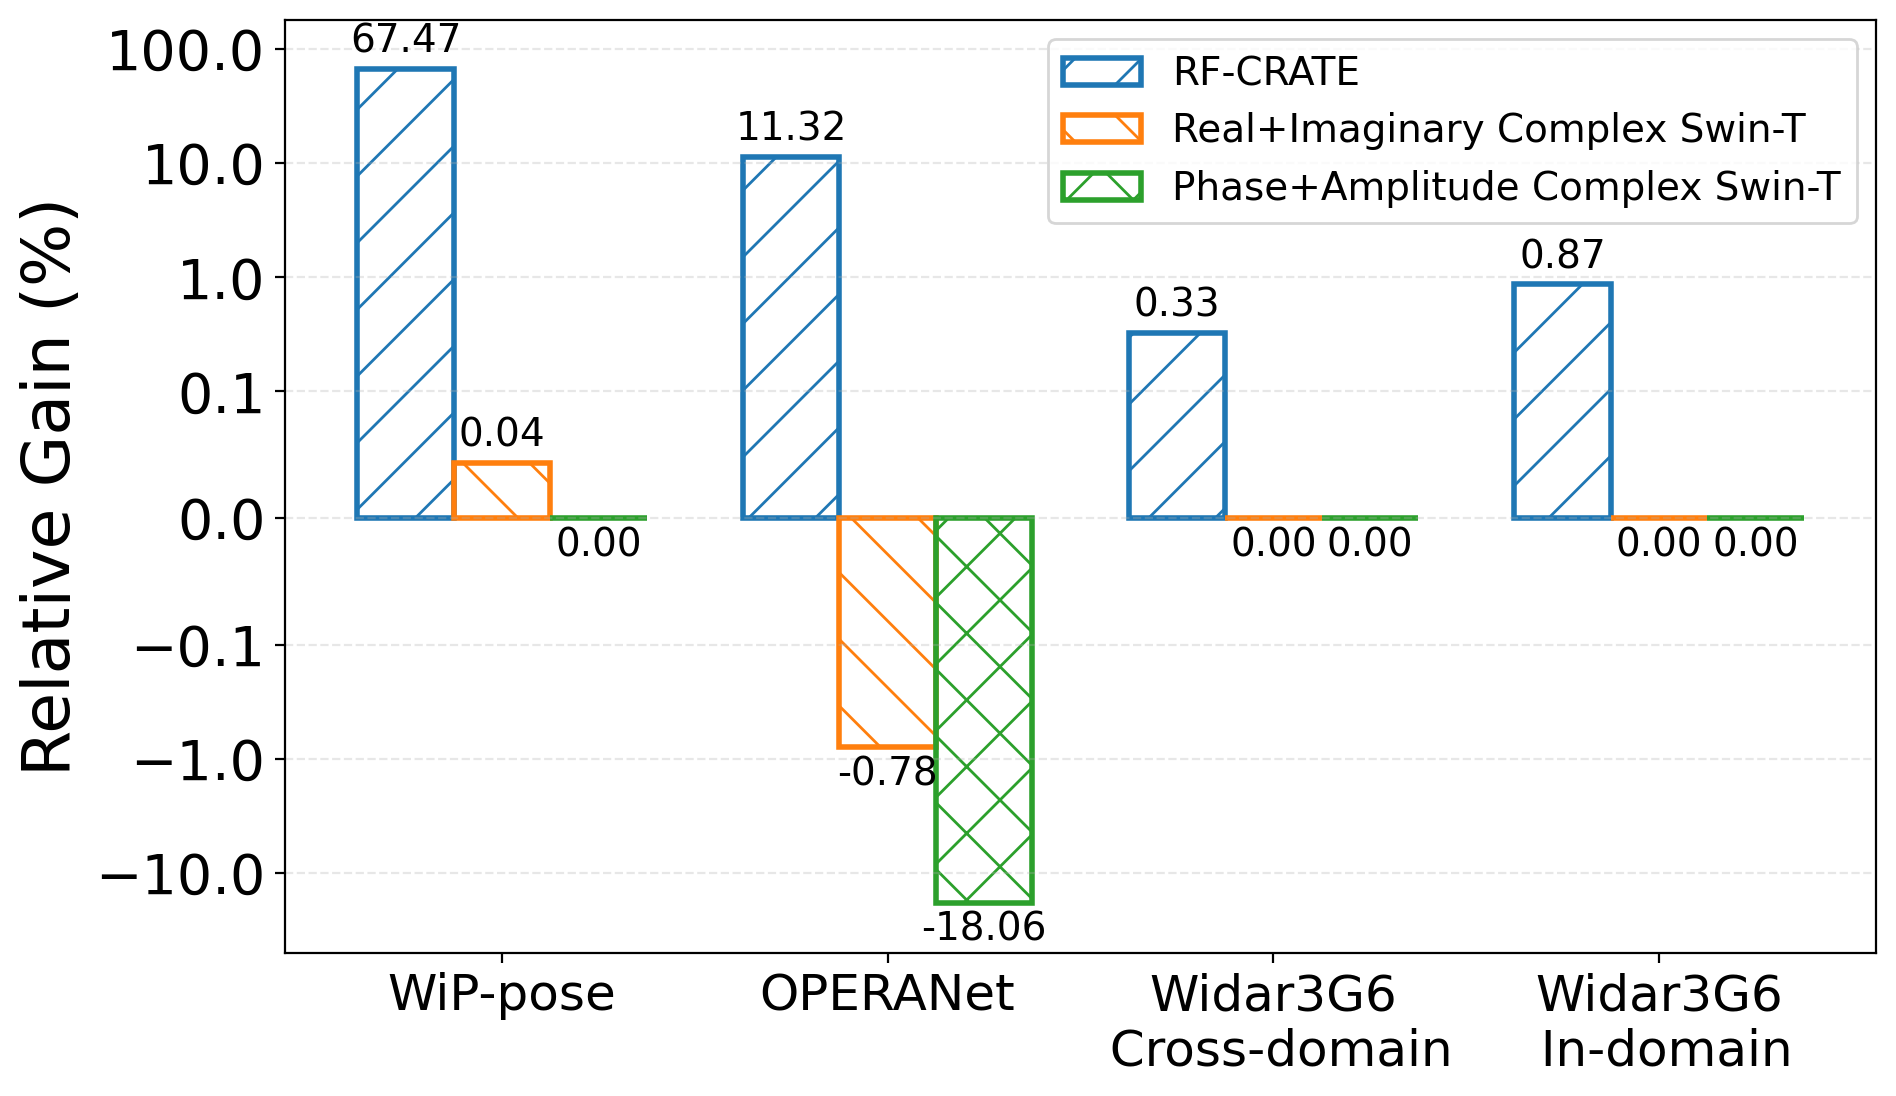

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter


dataset_names = list(rf_crate_performance_gains.keys())
values_model1 = list(rf_crate_performance_gains.values())
values_model2 = list(real_img_complex_swin_t_performance_gains.values())
values_model3 = list(phase_amp_complex_swin_t_performance_gains.values())

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

x = np.arange(len(dataset_names))
width = 0.25 

bars1 = ax.bar(x - width, values_model1, width=width, facecolor='none', hatch='/', 
               edgecolor='tab:blue', linewidth=2, label='RF-CRATE')
bars2 = ax.bar(x, values_model2, width=width, facecolor='none', hatch='\\', 
               edgecolor='tab:orange', linewidth=2, label='Real+Imaginary Complex Swin-T')
bars3 = ax.bar(x + width, values_model3, width=width, facecolor='none', hatch='x', 
               edgecolor='tab:green', linewidth=2, label='Phase+Amplitude Complex Swin-T')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        va = 'bottom' if height > 0 else 'top'
        offset = 3 if height > 0 else -3
        
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, offset),
                    textcoords="offset points",
                    ha='center', va=va, fontsize=14)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)


ax.set_yscale('symlog', linthresh=0.1) 

# Set appropriate limits for symlog
ax.set_ylim(-50, 180) 

# Formatting ticks
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis='both', which='major', labelsize=20)
# Optional: Set explicit ticks to clarify the log jumps
ax.set_yticks([-10, -1, -0.1, 0, 0.1, 1, 10, 100])

ax.set_ylabel('Relative Gain (%)', fontsize=24)
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, fontsize=18)
plt.grid(axis='y', which='both', linestyle='--', alpha=0.3)
ax.legend(fontsize=14, loc='upper right')
fig.tight_layout()
# plt.savefig("figures/V3_performance_gains_comparison_with_complex_swint.pdf", dpi=200, bbox_inches='tight')
plt.show()